In [2]:
!pip install emoji langdetect keybert sentence-transformers umap-learn -q
!pip install opentelemetry-api==1.25.0 opentelemetry-sdk==1.25.0 opentelemetry-exporter-otlp-proto-grpc==1.25.0 -q
!pip install chromadb --upgrade -q
!pip install gensim -q
!pip install pyLDAvis -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 27.8 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 36.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0d

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import emoji
import re
from collections import Counter
import matplotlib.pyplot as plt
import os
import random

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.util import ngrams

from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

from langdetect import detect, DetectorFactory
from keybert import KeyBERT
import umap

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

from gensim import corpora
from gensim.models import LsiModel, LdaModel, HdpModel, LdaMulticore
np.random.seed(SEED)
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import chromadb
from pathlib import Path

DB_PATH_RESUMENES = Path("/content/drive/MyDrive/NLP_PRACTICA/Persist/chroma_db_resumenes_qwen")
DB_PATH_LIBRO = "/content/drive/MyDrive/NLP_PRACTICA/Persist/libro_largo_qwen"
client_libro = chromadb.PersistentClient(path=DB_PATH_LIBRO)
coll_name_libro = client_libro.list_collections()[0].name

collection_libro = client_libro.get_collection(coll_name_libro)
COLLECTION_NAME = "resumenes_got"

client = chromadb.PersistentClient(path=str(DB_PATH_RESUMENES))
collection = client.get_collection(COLLECTION_NAME)

In [6]:
data = collection.get()
data_libro = collection_libro.get()

df_resumenes = pd.DataFrame({
    'ids': data['ids'],
    'documents': data['documents'],
    'metadatas': data['metadatas']
})

if df_resumenes['metadatas'].notnull().any():
    df_meta = pd.json_normalize(df_resumenes['metadatas'])
    df_resumenes = pd.concat([df_resumenes.drop('metadatas', axis=1), df_meta], axis=1)


df_libro = pd.DataFrame({
    'ids': data_libro['ids'],
    'documents': data_libro['documents'],
    'metadatas': data_libro['metadatas']
})

if df_libro['metadatas'].notnull().any():
    df_meta_libro = pd.json_normalize(df_libro['metadatas'])
    df_libro = pd.concat([df_libro.drop('metadatas', axis=1), df_meta_libro], axis=1)

df = pd.concat([df_resumenes, df_libro], ignore_index=True)

print(f"Total registros en df: {len(df)}")
display(df_libro.head(5))
display(df_resumenes.head(5))

Total registros en df: 648


,ids,documents,pov,keywords,locations,characters,chunk_index,chapter_title,houses,chapter_order,main_event,chapter_id
0,agot_001_bran_0,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,BRAN,"decapitación, justicia, rey, salvajes, Mance R...","Invernalia, el fortín de las colinas, el puente","Bran, Robb, Jon Nieve, Eddard Stark, Theon Gre...",0,BRAN (1),"Stark, Greyjoy, Baratheon",1,Bran presencia la decapitación de un hombre ac...,agot_001_bran
1,agot_001_bran_1,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,BRAN,"Bran, Robb, Jon, lobos huargos, nieve, Muro, S...","el norte del reino, el puente, el Muro","Bran, Robb, Jon, Jory, Theon Greyjoy, Hullen",1,BRAN (1),"Stark, Greyjoy",1,Bran y su hermano Robb encuentran lobos huargo...,agot_001_bran
2,agot_001_bran_2,Chapter: BRAN (1)\nChapter order: 1\nPOV: BRAN...,BRAN,"Bran, Jon, cachorros, lobos, Stark, Greyjoy, I...","Invernalia, el norte","Bran, Jory, Robb, Jon, Hullen, Theon Greyjoy, ...",2,BRAN (1),"Stark, Greyjoy",1,Bran y sus hermanos reciben cinco cachorros de...,agot_001_bran
3,agot_002_catelyn_0,Chapter: CATELYN (1)\nChapter order: 2\nPOV: C...,CATELYN,"Catelyn, Ned, Bosque de dioses, Aguasdulces, I...","Aguasdulces, Invernalia, El bosque de dioses, ...","Catelyn, Ned, Bran, Arya, Sansa, Rickon",0,CATELYN (1),"Tully, Stark",2,Catelyn se reúne con su esposo Ned en el bosqu...,agot_002_catelyn
4,agot_002_catelyn_1,Chapter: CATELYN (1)\nChapter order: 2\nPOV: C...,CATELYN,,,,1,CATELYN (1),,2,,agot_002_catelyn


,ids,documents,paragraph_id,chapter
0,Juego_de_Tronos-Prólogo_0,"Dos hombres de la Guardia de la Noche , Will y...",0,Juego de Tronos-Prólogo
1,Juego_de_Tronos-Prólogo_1,"Will le lleva allí, dejando atrás Gared para p...",1,Juego de Tronos-Prólogo
2,Juego_de_Tronos-Capítulo_1_0,"Bran viaja con su padre, Lord Eddard Stark , y...",0,Juego de Tronos-Capítulo 1
3,Juego_de_Tronos-Capítulo_1_1,"De camino a Invernalia , Robb y Jon discuten s...",1,Juego de Tronos-Capítulo 1
4,Juego_de_Tronos-Capítulo_1_2,Jon les alcanza para que vean lo que Robb y él...,2,Juego de Tronos-Capítulo 1


In [7]:
documents_libro = [str(text).split() for text in df_libro['documents']]

dictionary_libro = corpora.Dictionary(documents_libro)

corpus_libro = [dictionary_libro.doc2bow(doc) for doc in documents_libro]

documents_resumenes = [str(text).split() for text in df_resumenes['documents']]

dictionary_resumenes = corpora.Dictionary(documents_resumenes)

corpus_resumenes = [dictionary_resumenes.doc2bow(doc) for doc in documents_resumenes]

documents_total = [str(text).split() for text in df['documents']]

dictionary_total = corpora.Dictionary(documents_total)

corpus_total = [dictionary_total.doc2bow(doc) for doc in documents_total]


## Preprocesado y limpieza del corpus para Topic Modeling

Antes de aplicar los modelos de *Topic Modeling* mediante LDA (*Latent Dirichlet Allocation*), se realizó una fase de preprocesado específica orientada a mejorar la calidad semántica de los tópicos generados. El objetivo principal de esta etapa fue reducir el ruido lingüístico y estructural del corpus, preservando al mismo tiempo la información narrativa relevante.

### Eliminación de metadatos estructurales

Los fragmentos del corpus original incluían información auxiliar añadida durante la construcción de los *chunks*, como:

- títulos de capítulo,
- POV (*Point of View*),
- listas de personajes,
- localizaciones,
- palabras clave,
- eventos principales.

Aunque estos metadatos pueden ser útiles para tareas de recuperación o análisis descriptivo, introducen un sesgo artificial en LDA, ya que generan términos extremadamente frecuentes que no representan realmente el contenido temático de los textos.

Por este motivo, se eliminaron automáticamente todas las cabeceras y etiquetas estructurales mediante expresiones de limpieza específicas.

---

### Normalización del texto

El texto se transformó a minúsculas y se eliminaron caracteres no lingüísticos, manteniendo únicamente:

- letras,
- espacios,
- caracteres propios del español (`á`, `é`, `í`, `ó`, `ú`, `ü`, `ñ`).

Esta normalización reduce la fragmentación artificial del vocabulario y evita que diferentes variantes ortográficas de una misma palabra sean tratadas como términos distintos.

---

### Eliminación de *stopwords*

Se utilizaron las *stopwords* estándar de NLTK para español junto con varias listas adicionales diseñadas específicamente para este corpus narrativo.

#### Stopwords estructurales

Se eliminaron términos derivados de las etiquetas internas del dataset, como:

- `chapter`,
- `pov`,
- `characters`,
- `houses`,
- `locations`,
- `keywords`,
- `main event`.

Estos términos no aportan contenido semántico útil para la identificación de tópicos.

#### Stopwords narrativas

Debido a la naturaleza literaria del corpus, también se eliminaron expresiones narrativas extremadamente frecuentes que aparecían de forma transversal en prácticamente todos los capítulos, por ejemplo:

- verbos de diálogo (`dijo`, `preguntó`, `respondió`),
- verbos narrativos generales (`miró`, `pensó`, `parecía`),
- palabras excesivamente genéricas (`mano`, `ojos`, `momento`, `vida`).

Aunque estas palabras tienen significado lingüístico, su alta frecuencia y baja especificidad temática provocaban que varios tópicos se construyesen alrededor de patrones narrativos comunes en lugar de conceptos relevantes del universo de la obra.

El objetivo de esta eliminación no fue simplificar el lenguaje, sino aumentar la capacidad discriminativa del modelo.

---

### Conservación de entidades narrativas relevantes

A diferencia de otros enfoques clásicos de NLP, no se eliminaron nombres de personajes, lugares o casas nobiliarias, ya que en un corpus literario estas entidades constituyen parte fundamental de la estructura temática.

Por ejemplo, términos como:

- `tyrion`,
- `eddard`,
- `daenerys`,
- `lannister`,
- `guardia noche`

aportan una fuerte señal semántica y permiten que los tópicos reflejen facciones, tramas, localizaciones y relaciones narrativas reales.

---

### Normalización de aliases y variantes

También se aplicó una normalización manual de entidades para unificar distintas referencias a un mismo personaje. Por ejemplo:

- `ned` → `eddard`
- `dany` → `daenerys`

Esto evita dispersar frecuencia entre aliases diferentes y mejora la coherencia de los tópicos generados.

---

### Filtrado final de tokens

Finalmente, se eliminaron:

- tokens vacíos,
- palabras de longitud menor o igual a 2 caracteres,
- términos incluidos en las listas de stopwords.

El resultado final fue un corpus considerablemente más limpio y semánticamente más consistente, optimizado específicamente para técnicas de *Topic Modeling* narrativo mediante LDA.

In [8]:
# =========================
# LIMPIEZA REFINADA PARA LDA
# =========================
nltk.download("stopwords")

# =========================
# STOPWORDS
# =========================

stopwords_es = set(stopwords.words("spanish"))

stopwords_estructurales = {
    # Ruido estructural
    "chapter", "order", "pov", "characters", "houses",
    "locations", "keywords", "main", "event",
    "text", "na", "n",
}

stopwords_narrativas = {
    # Honoríficos y títulos
    "ser", "lord", "señor",

    # Narración extremadamente frecuente
    "dijo", "preguntó", "replicó", "respondió",
    "murmuró", "exclamó", "gritó", "susurró",
    "contestó", "añadió", "comentó",

    # Verbos narrativos frecuentes
    "miró", "vio", "parecía", "pensó",
    "sabía", "podía", "podría", "puede",
    "debía", "debe", "quería", "quiere",

    # Palabras demasiado generales
    "hombre", "hombres", "padre",
    "mano", "manos", "ojos", "voz",
    "lado", "momento", "años",
    "día", "vida", "vez", "tiempo",

    # Conectores todavía frecuentes
    "así", "cómo", "allí", "aquí",
    "después", "siempre", "bien",

    # Números escritos frecuentes
    "dos", "tres",
}

stopwords_totales = (
    stopwords_es
    | stopwords_estructurales
    | stopwords_narrativas
)

# =========================
# NORMALIZACIÓN DE ENTIDADES
# =========================

reemplazos_entidades = {
    "ned": "eddard",
    "dany": "daenerys",
}

# =========================
# LIMPIEZA DE METADATOS
# =========================

def quitar_metadatos_libro(texto):
    """
    Elimina cabeceras artificiales añadidas a los chunks del libro.
    """
    texto = str(texto)

    if "Text:" in texto:
        texto = texto.split("Text:", 1)[1]

    prefijos_metadatos = (
        "Chapter:",
        "Chapter order:",
        "POV:",
        "Characters:",
        "Houses:",
        "Locations:",
        "Keywords:",
        "Main event:",
    )

    lineas_limpias = []

    for linea in texto.splitlines():
        linea = linea.strip()

        if not linea:
            continue

        if linea.startswith(prefijos_metadatos):
            continue

        lineas_limpias.append(linea)

    return " ".join(lineas_limpias)

# =========================
# TOKENIZACIÓN FINAL
# =========================

def limpiar_y_tokenizar(texto):
    """
    Preprocesado optimizado para LDA narrativo.
    """

    texto = str(texto).lower()

    # Mantener caracteres españoles
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)

    tokens = texto.split()

    # Normalización de aliases
    tokens = [
        reemplazos_entidades.get(token, token)
        for token in tokens
    ]

    # Filtrado
    tokens_limpios = [
        token for token in tokens
        if token not in stopwords_totales
        and len(token) > 2
    ]

    return tokens_limpios




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
# =========================
# APLICACIÓN AL CORPUS
# =========================

df_libro = df_libro.copy()
df_resumenes = df_resumenes.copy()

# Libro
df_libro["documents_clean"] = (
    df_libro["documents"]
    .apply(quitar_metadatos_libro)
)

df_libro["tokens_clean"] = (
    df_libro["documents_clean"]
    .apply(limpiar_y_tokenizar)
)

# Resúmenes
df_resumenes["documents_clean"] = (
    df_resumenes["documents"]
    .astype(str)
)

df_resumenes["tokens_clean"] = (
    df_resumenes["documents_clean"]
    .apply(limpiar_y_tokenizar)
)

# =========================
# LISTAS FINALES
# =========================

documents_libro_clean = df_libro["tokens_clean"].tolist()
documents_resumenes_clean = df_resumenes["tokens_clean"].tolist()

documents_total_clean = (
    documents_libro_clean
    + documents_resumenes_clean
)


In [10]:
# =========================
# RECONSTRUCCIÓN GENSIM
# =========================
dictionary_libro_clean = corpora.Dictionary(documents_libro_clean)
dictionary_libro_clean.filter_extremes(
    no_below=3,
    no_above=0.60
)

corpus_libro_clean = [
    dictionary_libro_clean.doc2bow(doc)
    for doc in documents_libro_clean
]

dictionary_resumenes_clean = corpora.Dictionary(documents_resumenes_clean)
dictionary_resumenes_clean.filter_extremes(
    no_below=3,
    no_above=0.60
)

corpus_resumenes_clean = [
    dictionary_resumenes_clean.doc2bow(doc)
    for doc in documents_resumenes_clean
]

dictionary_total_clean = corpora.Dictionary(documents_total_clean)
dictionary_total_clean.filter_extremes(
    no_below=3,
    no_above=0.60
)

corpus_total_clean = [
    dictionary_total_clean.doc2bow(doc)
    for doc in documents_total_clean
]

# =========================
# RESUMEN
# =========================

print("Libro:")
print("Docs:", len(documents_libro_clean))
print("Vocabulario:", len(dictionary_libro_clean))

print("\nResúmenes:")
print("Docs:", len(documents_resumenes_clean))
print("Vocabulario:", len(dictionary_resumenes_clean))

print("\nTotal:")
print("Docs:", len(documents_total_clean))
print("Vocabulario:", len(dictionary_total_clean))

print("\nEjemplo tokens libro:")
print(documents_libro_clean[0][:80])

print("\nEjemplo tokens resumen:")
print(documents_resumenes_clean[0][:80])

Libro:
Docs: 328
Vocabulario: 7037

Resúmenes:
Docs: 320
Vocabulario: 1265

Total:
Docs: 648
Vocabulario: 7609

Ejemplo tokens libro:
['bran', 'amanecido', 'fresco', 'despejado', 'frío', 'vivificante', 'señalaba', 'final', 'verano', 'pusieron', 'marcha', 'aurora', 'ver', 'decapitación', 'veinte', 'total', 'bran', 'cabalgaba', 'nervioso', 'emocionado', 'primera', 'consideraban', 'suficientemente', 'mayor', 'acompañar', 'hermanos', 'presenciar', 'justicia', 'rey', 'corría', 'noveno', 'año', 'verano', 'séptimo', 'bran', 'sacado', 'pequeño', 'fortín', 'colinas', 'robb', 'creía', 'trataba', 'salvaje', 'puesto', 'espada', 'servicio', 'mance', 'rayder', 'rey', 'allá', 'muro', 'bran', 'ponía', 'carne', 'gallina', 'sólo', 'pensarlo', 'recordaba', 'historias', 'vieja', 'tata', 'contado', 'junto', 'chimenea', 'salvajes', 'crueles', 'decía', 'esclavistas', 'asesinos', 'ladrones', 'apareaban', 'gigantes', 'espíritus', 'malignos', 'llevaban', 'niños', 'cunas', 'mitad', 'noche', 'bebían']

Ejemplo to

In [11]:
lda_model_libro = LdaModel(corpus=corpus_libro_clean, id2word=dictionary_libro_clean, num_topics=7, random_state=42, passes=15, chunksize=200, alpha='auto', per_word_topics=True)

lda_model_resumenes = LdaModel(corpus=corpus_resumenes_clean, id2word=dictionary_resumenes_clean, num_topics=4, random_state=42, passes=15, chunksize=200, alpha='auto', per_word_topics=True)

lda_model_total = LdaModel(corpus=corpus_total_clean, id2word=dictionary_total_clean, num_topics=10, random_state=42, passes=15, chunksize=200, alpha='auto', per_word_topics=True)

In [ ]:
def evaluate_graph(dictionary, corpus, texts, limit, start=2):

    c_scores = []
    models = []

    for k in range(start, limit + 1):

        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=42,
            passes=15,
            chunksize=200,
            alpha='auto',
            per_word_topics=True
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )

        coherence = coherence_model.get_coherence()

        c_scores.append(coherence)
        models.append(model)

        print(f"K={k} -> Coherencia: {coherence:.4f}")

    return models, c_scores

In [ ]:
limit_k = 30
start_k = 2

models_libro, scores_libro = evaluate_graph(
    dictionary_libro_clean,
    corpus_libro_clean,
    documents_libro_clean,
    limit_k,
    start=start_k
)

k_values = list(range(start_k, limit_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_libro, marker='o')

plt.xlabel("Número de tópicos")
plt.ylabel("Coherence score (c_v)")
plt.title("Búsqueda del K óptimo - Libro")

plt.grid(True)
plt.show()

best_index_libro = np.argmax(scores_libro)

best_k_libro = k_values[best_index_libro]

lda_model_libro = models_libro[best_index_libro]

print(f"Mejor número de temas: {best_k_libro}")
print(f"Mejor coherencia: {scores_libro[best_index_libro]:.4f}")

In [ ]:
models_resumenes, scores_resumenes = evaluate_graph(
    dictionary_resumenes_clean,
    corpus_resumenes_clean,
    documents_resumenes_clean,
    limit_k,
    start=start_k
)

k_values = list(range(start_k, limit_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_resumenes, marker='o')

plt.xlabel("Número de tópicos")
plt.ylabel("Coherence score (c_v)")
plt.title("Búsqueda del K óptimo - Resúmenes")

plt.grid(True)
plt.show()

best_index_resumenes = np.argmax(scores_resumenes)

best_k_resumenes = k_values[best_index_resumenes]

lda_model_resumenes = models_resumenes[best_index_resumenes]

print(f"Mejor número de temas: {best_k_resumenes}")
print(f"Mejor coherencia: {scores_resumenes[best_index_resumenes]:.4f}")

In [ ]:
models_total, scores_total = evaluate_graph(
    dictionary_total_clean,
    corpus_total_clean,
    documents_total_clean,
    limit_k,
    start=start_k
)

k_values = list(range(start_k, limit_k + 1))

plt.figure(figsize=(10, 5))
plt.plot(k_values, scores_total, marker='o')

plt.xlabel("Número de tópicos")
plt.ylabel("Coherence score (c_v)")
plt.title("Búsqueda del K óptimo - Corpus Total")

plt.grid(True)
plt.show()

best_index_total = np.argmax(scores_total)

best_k_total = k_values[best_index_total]

lda_model_total = models_total[best_index_total]

print(f"Mejor número de temas: {best_k_total}")
print(f"Mejor coherencia: {scores_total[best_index_total]:.4f}")

Vamos a analizar los resultados:

- En la colección del libro, la K optima es de 7. Consideramos que es un buen valor, pues hay 8 POVS en el libro. El valor de la coherencia, de 0.51, puede considerarse como suficiente

- En la colección de los resumenes, la K optima es de 4, algo baja. No obstante, la coherencia no es mala (0.5188). 

- En cambio, en la colección total, la K optima vuelve a subir hasta los 10, con una coherencia de 0.5353, la máxima de las tres.

Una vez tenemos los modelos, vamos a empezar por analizar los topics de forma manual viendo las palabras clave e cada uno, para ver si vemos algo interesante.

In [12]:
for idx, topic in lda_model_libro.print_topics(num_words=15):
    print("\n" + "=" * 80)
    print(f"TÓPICO {idx}")
    print("=" * 80)
    print(topic)


TÓPICO 0
0.014*"eddard" + 0.010*"tyrion" + 0.009*"catelyn" + 0.008*"lannister" + 0.006*"hijo" + 0.006*"robert" + 0.005*"stark" + 0.004*"robb" + 0.003*"tywin" + 0.003*"gran" + 0.003*"hijos" + 0.003*"señores" + 0.003*"jaime" + 0.003*"casa" + 0.003*"dioses"

TÓPICO 1
0.021*"jon" + 0.012*"bran" + 0.006*"maestre" + 0.005*"robb" + 0.005*"noche" + 0.005*"espada" + 0.004*"muro" + 0.004*"mormont" + 0.004*"luwin" + 0.004*"dioses" + 0.003*"guardia" + 0.003*"lobo" + 0.003*"nieve" + 0.003*"stark" + 0.003*"fantasma"

TÓPICO 2
0.017*"arya" + 0.015*"syrio" + 0.014*"espada" + 0.007*"madera" + 0.006*"izquierda" + 0.006*"forel" + 0.006*"lanzó" + 0.005*"eddard" + 0.005*"cayó" + 0.005*"espadas" + 0.005*"guardia" + 0.005*"acero" + 0.005*"puerta" + 0.005*"gato" + 0.005*"capas"

TÓPICO 3
0.059*"arya" + 0.010*"sansa" + 0.008*"joffrey" + 0.007*"aguja" + 0.005*"septa" + 0.005*"espada" + 0.005*"chico" + 0.005*"loba" + 0.005*"nymeria" + 0.005*"príncipe" + 0.004*"niña" + 0.004*"capas" + 0.004*"multitud" + 0.004*"v

Entre los 7 topics, parece ver algo más o menos claro:

- Topic 0: Parece que es el Topic de Ned y todo lo que le rodea.
- Topic 1: Parece el Topic de Jon Nieve y todo lo que tien que ver con el muro (Jon, Muro, Mormont...)
- Topic 2: Parece la trama de Arya, cuando le dan la espada, cuando entrena con Syrio...
- Topic 3: Parece la trama de Arya con su familia, cuando se enfrenta al principe Joffrey...
- Topic 4: Parece todo el Topic de Daenerys, con Khal, los dragones...
- Topic 5: Parece todo lo que tiene que ver con la captura de Tyrion y su viaje al Nido de Águilas
- Topic 6: Paraece todo lo que tien eque ver con los Lannister y Sansa en Desembarco del Rey-

A simple vista, parece que los Topics están muy muy bien separados.

In [13]:
for idx, topic in lda_model_resumenes.print_topics(num_words=15):
    print("\n" + "=" * 80)
    print(f"TÓPICO {idx}")
    print("=" * 80)
    print(topic)


TÓPICO 0
0.038*"eddard" + 0.021*"dice" + 0.019*"sansa" + 0.017*"robert" + 0.016*"bran" + 0.016*"arya" + 0.015*"rey" + 0.015*"joffrey" + 0.010*"maestre" + 0.008*"cersei" + 0.008*"pregunta" + 0.007*"jon" + 0.007*"acerca" + 0.007*"robb" + 0.007*"guardia"

TÓPICO 1
0.056*"daenerys" + 0.033*"drogo" + 0.033*"viserys" + 0.024*"jorah" + 0.016*"khal" + 0.013*"dothraki" + 0.013*"sangre" + 0.011*"dice" + 0.009*"dragón" + 0.008*"hermano" + 0.008*"jinetes" + 0.007*"khalasar" + 0.006*"caballo" + 0.006*"hijo" + 0.006*"pregunta"

TÓPICO 2
0.057*"jon" + 0.018*"mormont" + 0.014*"dice" + 0.014*"noche" + 0.013*"fantasma" + 0.011*"muro" + 0.011*"samwell" + 0.011*"guardia" + 0.009*"aemon" + 0.009*"espada" + 0.009*"sam" + 0.009*"negro" + 0.009*"tyrion" + 0.008*"comandante" + 0.008*"lobo"

TÓPICO 3
0.023*"tyrion" + 0.020*"catelyn" + 0.016*"jon" + 0.015*"stark" + 0.015*"lannister" + 0.015*"rey" + 0.014*"robb" + 0.012*"dice" + 0.010*"eddard" + 0.009*"pregunta" + 0.008*"hijo" + 0.008*"ejército" + 0.007*"hermano

En este caso, tenemos menos topics. Veamos que intenta representar cada uno:

- Topic 0: Parece todo lo que tiene que ver con los Stark en general; desde Eddard y sansa, hasta maestre...
- Topic 1: Todo lo que tiene que ver con los Targaryen y Daenerys.
- Topic 2: Todo lo que tiene que ver con el muro y Jon Nieve, que es una trama a parte de los Stark.
- Topic 3: Todo lo que tiene que ver con los Lannister, la captura de Tyrion y Catelyn...

Nuevamente, aunque con menos Topics, parece captar muy bien las 4 tramas principales del libro y las familias más importantes.

In [14]:
for idx, topic in lda_model_total.print_topics(num_words=15):
    print("\n" + "=" * 80)
    print(f"TÓPICO {idx}")
    print("=" * 80)
    print(topic)


TÓPICO 0
0.015*"tyrion" + 0.006*"espada" + 0.006*"hacia" + 0.006*"cabeza" + 0.006*"tan" + 0.005*"mientras" + 0.005*"dio" + 0.004*"rostro" + 0.004*"hizo" + 0.004*"chico" + 0.004*"stark" + 0.003*"puerta" + 0.003*"ver" + 0.003*"lannister" + 0.003*"caballero"

TÓPICO 1
0.007*"tan" + 0.007*"hermano" + 0.005*"dioses" + 0.005*"mientras" + 0.004*"caballo" + 0.004*"sólo" + 0.004*"hijo" + 0.004*"hijos" + 0.004*"hacia" + 0.003*"eddard" + 0.003*"casa" + 0.003*"siete" + 0.003*"rey" + 0.003*"quiero" + 0.003*"aquel"

TÓPICO 2
0.043*"eddard" + 0.028*"rey" + 0.018*"robert" + 0.013*"lannister" + 0.012*"dice" + 0.010*"tyrion" + 0.010*"stark" + 0.008*"jaime" + 0.008*"cersei" + 0.007*"reina" + 0.007*"tywin" + 0.006*"meñique" + 0.006*"varys" + 0.006*"joffrey" + 0.006*"gran"

TÓPICO 3
0.099*"catelyn" + 0.024*"lysa" + 0.022*"frey" + 0.021*"robb" + 0.019*"aguasdulces" + 0.018*"lady" + 0.016*"rodrik" + 0.015*"hijo" + 0.014*"tully" + 0.014*"señora" + 0.011*"lannister" + 0.011*"brynden" + 0.011*"walder" + 0.010*

Para terminar, veamos qué nos dicen los topics del corpus total.

- Topic 0: No se ve un tema claro, pero si que parece que tien que ver con algo de Tyrion y los lannister.
- Topic 1: Tampoco se ve nada claro.
- Topic 2: Parece ser algo sobre Ned y su trama con los Lannister.
- Topic 3: Parece que tiene que ver con todo lo que hace Catelyn y su familia de aguas dulces.
- Topic 4: Parece que tiene que ver con Arya, su entrenamiento, su estancia en desembarco...
- Topic 5: Todo lo que tiene que ver con Daenerys.
- Topic 6: Todo lo que tiene que ver con Jon Nieve y el muro
- Topic 7: Nada claro, palabras vacias.
- Topic 8: Toda la trama de Bran cuando se queda lisiado en Invernalia
- Topic 9: Nada claro

Nuevamente, algunos topics si que parecen interesantes, pero otros no aportan información. 

Es decir, parece que las colecciones por separado tienen mucho sentido, pero juntas no tanto. Tiene sentido, pues aunque cuenten lo mismo, una lo hace con mucho más detalle que otra.

Para seguir con el análisis, veamos que Topic domina por POV en la coleccion de los libros. A partir de ahora, utilizaremos el TM de cada colección por separado, porque hemos visto que tienen mucho más sentido con el análisis anterior.

In [15]:
# =========================
# TÓPICO DOMINANTE POR CHUNK DEL LIBRO
# =========================

def obtener_topico_dominante(modelo, corpus):
    resultados = []

    for i, bow in enumerate(corpus):
        distribucion = modelo.get_document_topics(bow, minimum_probability=0.0)

        topic_id, topic_prob = max(distribucion, key=lambda x: x[1])

        resultados.append({
            "doc_idx": i,
            "topic_id": topic_id,
            "topic_prob": topic_prob
        })

    return pd.DataFrame(resultados)


df_topics_libro = obtener_topico_dominante(
    lda_model_libro,
    corpus_libro_clean
)

df_libro_topics = df_libro.copy()
df_libro_topics["topic_id"] = df_topics_libro["topic_id"]
df_libro_topics["topic_prob"] = df_topics_libro["topic_prob"]


In [16]:
# =========================
# CONTEO DE TÓPICOS DOMINANTES POR POV
# =========================

tabla_pov_topic_abs = (
    df_libro_topics
    .groupby(["pov", "topic_id"])
    .size()
    .unstack(fill_value=0)
)

display(tabla_pov_topic_abs)

topic_id,0,1,2,3,4,6
pov,,,,,,
ARYA,3,11,3,5,0,0
BRAN,0,30,0,0,0,0
CATELYN,49,5,0,0,0,0
DAENERYS,5,0,0,1,45,0
EDDARD,60,0,2,0,0,0
JON,1,38,0,0,0,0
SANSA,6,2,0,2,0,16
TYRION,36,8,0,0,0,0


In [17]:
# =========================
# PROPORCIÓN DE TÓPICOS DOMINANTES POR POV
# =========================

tabla_pov_topic_pct = tabla_pov_topic_abs.div(
    tabla_pov_topic_abs.sum(axis=1),
    axis=0
)

display(tabla_pov_topic_pct.round(3))

topic_id,0,1,2,3,4,6
pov,,,,,,
ARYA,0.136,0.500,0.136,0.227,0.000,0.000
BRAN,0.000,1.000,0.000,0.000,0.000,0.000
CATELYN,0.907,0.093,0.000,0.000,0.000,0.000
DAENERYS,0.098,0.000,0.000,0.020,0.882,0.000
EDDARD,0.968,0.000,0.032,0.000,0.000,0.000
JON,0.026,0.974,0.000,0.000,0.000,0.000
SANSA,0.231,0.077,0.000,0.077,0.000,0.615
TYRION,0.818,0.182,0.000,0.000,0.000,0.000


In [18]:
# =========================
# TÓPICO DOMINANTE PRINCIPAL POR POV
# =========================

topic_principal_por_pov = (
    tabla_pov_topic_pct
    .idxmax(axis=1)
    .reset_index()
)

topic_principal_por_pov.columns = ["pov", "topic_id_principal"]

topic_principal_por_pov["proporcion"] = topic_principal_por_pov.apply(
    lambda row: tabla_pov_topic_pct.loc[row["pov"], row["topic_id_principal"]],
    axis=1
)

display(topic_principal_por_pov.sort_values("proporcion", ascending=False))

,pov,topic_id_principal,proporcion
1,BRAN,1,1.000000
5,JON,1,0.974359
4,EDDARD,0,0.967742
2,CATELYN,0,0.907407
3,DAENERYS,4,0.882353
7,TYRION,0,0.818182
6,SANSA,6,0.615385
0,ARYA,1,0.500000


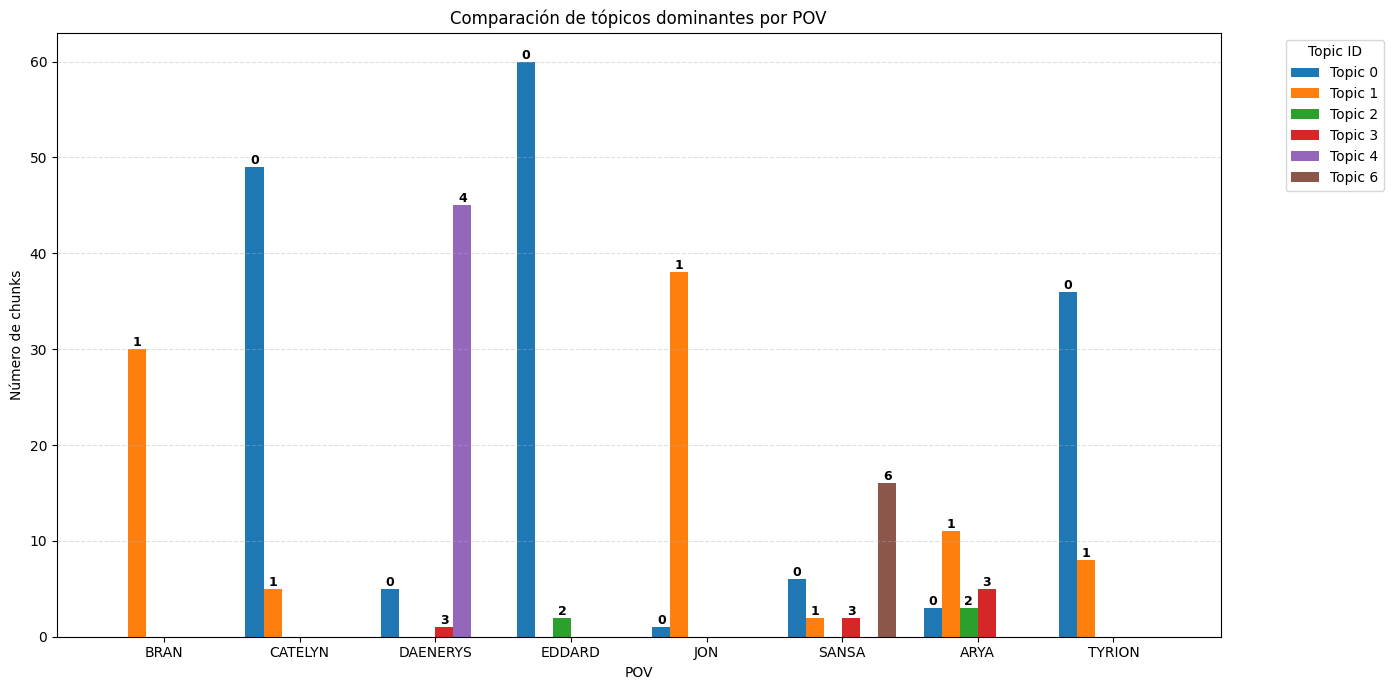

In [19]:
# =========================
# BARRAS AGRUPADAS:
# TOPICS DOMINANTES POR POV
# =========================

import numpy as np
import matplotlib.pyplot as plt

tabla_pov_topic_abs = (
    df_libro_topics
    .groupby(["pov", "topic_id"])
    .size()
    .unstack(fill_value=0)
)

orden_povs = [
    "BRAN",
    "CATELYN",
    "DAENERYS",
    "EDDARD",
    "JON",
    "SANSA",
    "ARYA",
    "TYRION"
]

tabla_pov_topic_abs = tabla_pov_topic_abs.reindex(orden_povs)

povs = tabla_pov_topic_abs.index.tolist()
topics = tabla_pov_topic_abs.columns.tolist()

x = np.arange(len(povs))
n_topics = len(topics)
width = 0.8 / n_topics

plt.figure(figsize=(14, 7))

for i, topic_id in enumerate(topics):
    valores = tabla_pov_topic_abs[topic_id].values

    posiciones = x - 0.4 + width / 2 + i * width

    plt.bar(
        posiciones,
        valores,
        width=width,
        label=f"Topic {topic_id}"
    )

    # Etiqueta del topic sobre cada barra
    for pos, valor in zip(posiciones, valores):
        if valor > 0:
            plt.text(
                pos,
                valor,
                str(topic_id),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

plt.xticks(x, povs, rotation=0)
plt.xlabel("POV")
plt.ylabel("Número de chunks")
plt.title("Comparación de tópicos dominantes por POV")

plt.legend(
    title="Topic ID",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Como podemos ver en la gráfica de arriba, vemos que Daenerys destaca especialmente porque es la única que tiene el Topic 4, además como dominante. Esto tiene muchisimo sentido porque Daenerys se encuentra en otro continente con una trama muy separada.

Por otro lado, vemos que Bran y Jon tienen el Topic 1 como el dominante (en el caso de Bran, solo tiene ese topic). Tiene sentido pues Bran y Jon Nieve son los personajes que se quedan en el Norte, uno en Invernalia y otro en el Muro, con tramas parecidas.

En cambio, Catelyn, Eddard y Tyrion tienen topics parecidos, pues son los personajes más importantes en lo que a la trama del Sur se refiere. Por ejemplo, Catelyn y Tyrion pasan mucho tiempo juntos. Eddard en cambio está en el Sur con todas las tramas políticas. Estas tramas son consecuencia de la decisión de Catelyn de atrapar a Tyrion.

Mientras tanto, Sansa y Arya tienen un surtido de Topics. Sansa destaca en el Topic 6, con presencia también del 0 (el de la política). Si bien Sansa es hija de Eddard y Catelyn, pasa más tiempo con los Lannister y tiene tramas "separadas" dentro de la trama del Sur. Arya, por otro lado, aparece de forma dispersa con Topics diferentes. Es la hermana que más relación tiene con Jon, lo que explicaría su presencia del Topic 1.

Podemos concluir que los Topics están más o menos bien repartidos y tienen sentido dentro del mundo del libro. Ahora, hagamos algo parecido con la colección de los resumenes. El problema es que en la colección de los resumenes no tenemos el POV de cada capítulo. No obstante, podemos inferirlo de la colección de los libros:

In [20]:
# =========================
# INFERIR POV EN RESÚMENES
# A PARTIR DE df_libro
# =========================

# 1. Crear mapa chapter_order -> POV desde el libro
mapa_capitulo_pov = (
    df_libro[["chapter_order", "pov"]]
    .drop_duplicates()
    .set_index("chapter_order")["pov"]
    .to_dict()
)

# 2. Extraer número de capítulo en df_resumenes
def extraer_numero_capitulo_resumen(chapter):
    chapter = str(chapter)

    match = re.search(r"Capítulo\s+(\d+)", chapter)

    if match:
        return int(match.group(1))

    return np.nan  # Prólogo u otros casos sin número


df_resumenes_topics = df_resumenes.copy()

df_resumenes_topics["chapter_order"] = (
    df_resumenes_topics["chapter"]
    .apply(extraer_numero_capitulo_resumen)
)

# 3. Asignar POV inferido
df_resumenes_topics["pov_inferido"] = (
    df_resumenes_topics["chapter_order"]
    .map(mapa_capitulo_pov)
)

# Opcional: eliminar prólogo, porque no tiene POV equivalente en df_libro
df_resumenes_topics = df_resumenes_topics.dropna(subset=["pov_inferido"]).copy()

df_resumenes_topics[["chapter", "chapter_order", "pov_inferido"]].head(10)

,chapter,chapter_order,pov_inferido
2,Juego de Tronos-Capítulo 1,1.0,BRAN
3,Juego de Tronos-Capítulo 1,1.0,BRAN
4,Juego de Tronos-Capítulo 1,1.0,BRAN
5,Juego de Tronos-Capítulo 1,1.0,BRAN
6,Juego de Tronos-Capítulo 1,1.0,BRAN
7,Juego de Tronos-Capítulo 10,10.0,JON
8,Juego de Tronos-Capítulo 10,10.0,JON
9,Juego de Tronos-Capítulo 11,11.0,DAENERYS
10,Juego de Tronos-Capítulo 11,11.0,DAENERYS
11,Juego de Tronos-Capítulo 11,11.0,DAENERYS


In [21]:
# =========================
# TÓPICO DOMINANTE EN RESÚMENES
# =========================

def obtener_topico_dominante(modelo, corpus):
    resultados = []

    for i, bow in enumerate(corpus):
        distribucion = modelo.get_document_topics(
            bow,
            minimum_probability=0.0
        )

        topic_id, topic_prob = max(distribucion, key=lambda x: x[1])

        resultados.append({
            "doc_idx": i,
            "topic_id": topic_id,
            "topic_prob": topic_prob
        })

    return pd.DataFrame(resultados)


df_topics_resumenes = obtener_topico_dominante(
    lda_model_resumenes,
    corpus_resumenes_clean
)

df_resumenes_topics_full = df_resumenes.copy()
df_resumenes_topics_full["topic_id"] = df_topics_resumenes["topic_id"]
df_resumenes_topics_full["topic_prob"] = df_topics_resumenes["topic_prob"]

df_resumenes_topics_full["chapter_order"] = (
    df_resumenes_topics_full["chapter"]
    .apply(extraer_numero_capitulo_resumen)
)

df_resumenes_topics_full["pov_inferido"] = (
    df_resumenes_topics_full["chapter_order"]
    .map(mapa_capitulo_pov)
)

# Quitamos el prólogo
df_resumenes_topics_full = (
    df_resumenes_topics_full
    .dropna(subset=["pov_inferido"])
    .copy()
)

df_resumenes_topics_full[[
    "chapter",
    "chapter_order",
    "pov_inferido",
    "topic_id",
    "topic_prob"
]].head()

,chapter,chapter_order,pov_inferido,topic_id,topic_prob
2,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.992958
3,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.615799
4,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.987124
5,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.988258
6,Juego de Tronos-Capítulo 1,1.0,BRAN,0,0.982944


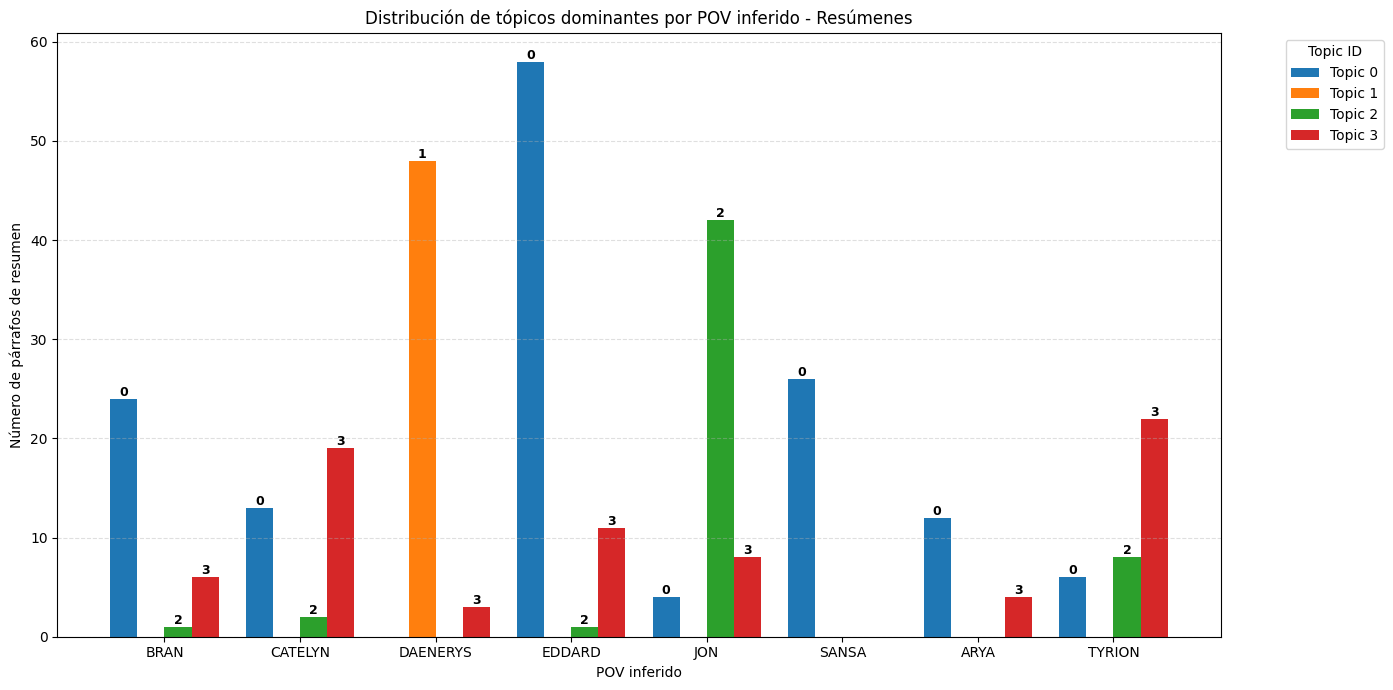

In [22]:
# =========================
# BARRAS AGRUPADAS:
# TOPICS DOMINANTES POR POV INFERIDO EN RESÚMENES
# =========================

tabla_pov_topic_resumenes = (
    df_resumenes_topics_full
    .groupby(["pov_inferido", "topic_id"])
    .size()
    .unstack(fill_value=0)
)

orden_povs = [
    "BRAN",
    "CATELYN",
    "DAENERYS",
    "EDDARD",
    "JON",
    "SANSA",
    "ARYA",
    "TYRION"
]

tabla_pov_topic_resumenes = tabla_pov_topic_resumenes.reindex(orden_povs)

povs = tabla_pov_topic_resumenes.index.tolist()
topics = tabla_pov_topic_resumenes.columns.tolist()

x = np.arange(len(povs))
n_topics = len(topics)
width = 0.8 / n_topics

plt.figure(figsize=(14, 7))

for i, topic_id in enumerate(topics):
    valores = tabla_pov_topic_resumenes[topic_id].values
    posiciones = x - 0.4 + width / 2 + i * width

    plt.bar(
        posiciones,
        valores,
        width=width,
        label=f"Topic {topic_id}"
    )

    for pos, valor in zip(posiciones, valores):
        if valor > 0:
            plt.text(
                pos,
                valor,
                str(topic_id),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

plt.xticks(x, povs, rotation=0)
plt.xlabel("POV inferido")
plt.ylabel("Número de párrafos de resumen")
plt.title("Distribución de tópicos dominantes por POV inferido - Resúmenes")

plt.legend(
    title="Topic ID",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Al igual que antes, Daenerys es la única con un Topic único, el 1 en este caso. Como antes, esto tiene mucho sentido.

Por otro lado, Eddard, Bran, Sansa Y Arya (los Stark verdaderos), tienen como Topic dominante el 0

Jon por otro lado tiene como dominante el 2, pues es el que está en el muro. Tyrion comparte parte del 2 con él porque en su viaje al muro, Tyrion acompaña a Jon y se hacen amigos.

Finalmente, Tyrion y Catelyn comparten el Topic 3 como principal por lo comentado anteriormente de que comparten mucho tiempo juntos.

Nuevamente, aunque con menos Topics, tienen sentido como están distribuidos.

## Sesgos
